##  Getting started with Biopython

### Reading Sequence Records
The first step in any bioinformatics project is reading and parsing the sequence data. We use the **`SeqIO`** module from Biopython, which is designed to handle common file formats like FASTA. Each record read contains essential information: the actual sequence data (`.seq`), the unique identifier (`.id`), and a detailed description (`.description`).

### The Central Dogma
The central dogma describes the fundamental flow of genetic information within a biological system:

$$\text{DNA} \xrightarrow{\text{Transcription}} \text{mRNA} \xrightarrow{\text{Translation}} \text{Protein}$$

* **Transcription:** The process where a DNA template is copied into messenger RNA (**mRNA**). Biologically, the nucleotide **Thymine (T)** in DNA is replaced by **Uracil (U)** in RNA. Biopython handles this substitution with a single method call.
* **Translation:** The mRNA sequence is decoded in triplets (**codons**) by the ribosome. Each codon specifies a particular amino acid, building the final chain known as a **protein**.

# Reading Data File (fasta)
Data was downloaded from Genecode
[Human Protein-coding transcript sequences](https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_human/release_49/gencode.v49.pc_transcripts.fa.gz)

Installed : BioPython (`!pip install biopython`)


In [1]:
import Bio
print(Bio.__version__)

1.86


In [2]:
from pathlib import Path
current_dir = Path.cwd()
data_dir = f'{current_dir.parent.parent}/data'
file_name = 'gencode.v49.pc_transcripts.fa'

In [3]:
from Bio import SeqIO
from collections import Counter
from Bio.Seq import Seq
import pandas as pd
import matplotlib.pyplot as plt

/home/sud/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [4]:
sequences = SeqIO.parse(f'{data_dir}/{file_name}', 'fasta')

In [5]:
sequences = list(sequences)
print(len(sequences))

245535


In [6]:
for record in sequences:
    example = record
    print(example)
    break # print first record only

ID: ENST00000641515.2|ENSG00000186092.7|OTTHUMG00000001094.4|OTTHUMT00000003223.4|OR4F5-201|OR4F5|2618|UTR5:1-60|CDS:61-1041|UTR3:1042-2618|
Name: ENST00000641515.2|ENSG00000186092.7|OTTHUMG00000001094.4|OTTHUMT00000003223.4|OR4F5-201|OR4F5|2618|UTR5:1-60|CDS:61-1041|UTR3:1042-2618|
Description: ENST00000641515.2|ENSG00000186092.7|OTTHUMG00000001094.4|OTTHUMT00000003223.4|OR4F5-201|OR4F5|2618|UTR5:1-60|CDS:61-1041|UTR3:1042-2618|
Number of features: 0
Seq('CCCAGATCTCTTCAGTTTTTATGCCTCATTCTGTGAAAATTGCTGTAGTCTCTT...AAC')


In [7]:
type(example)

Bio.SeqRecord.SeqRecord

In [8]:
# Access id
example.id

'ENST00000641515.2|ENSG00000186092.7|OTTHUMG00000001094.4|OTTHUMT00000003223.4|OR4F5-201|OR4F5|2618|UTR5:1-60|CDS:61-1041|UTR3:1042-2618|'

In [9]:
# Dscription
example.description

'ENST00000641515.2|ENSG00000186092.7|OTTHUMG00000001094.4|OTTHUMT00000003223.4|OR4F5-201|OR4F5|2618|UTR5:1-60|CDS:61-1041|UTR3:1042-2618|'

In [10]:
# sequence
example.seq

Seq('CCCAGATCTCTTCAGTTTTTATGCCTCATTCTGTGAAAATTGCTGTAGTCTCTT...AAC')

In [15]:
example.seq.complement()

Seq('GGGTCTAGAGAAGTCAAAAATACGGAGTAAGACACTTTTAACGACATCAGAGAA...TTG')

In [17]:
example.seq.reverse_complement()

Seq('GTTTTTTTGAAAAAAGAGTTATGTCTTGAATTCACTTAGAGATTGTCCTGGCAT...GGG')

In [20]:
example.seq.count('GG')

77

##### MutableSeq

Just like the normal Python string, the Seq object is “read only”, or in **Python terminology, immutable.**

To change the seuquences MutableSeq is required

In [28]:
from Bio.Seq import MutableSeq
mutable_seq = MutableSeq(example.seq)
mutable_seq

MutableSeq('CCCAGATCTCTTCAGTTTTTATGCCTCATTCTGTGAAAATTGCTGTAGTCTCTT...AAC')

#### GC Fraction

In [21]:
from Bio.SeqUtils import gc_fraction
gc_fraction(example.seq)

0.35943468296409475

### CDS
CDS -> CoDing Sequence (or some people call it Coding DNA Sequence)

The location of this sequence is provided in the Description of the record (**Use 0 indexing in python so start at 60**)

In [11]:
CDS = example.seq[60:1041]
CDS

Seq('ATGAAGAAGGTAACTGCAGAGGCTATTTCCTGGAATGAATCAACGAGTGAAACG...TAG')

### Transcription and Translation

In [12]:
# Transcription (DNA to mRNA)
mrna_sequence = CDS.transcribe()
print(f"mRNA Sequence: {mrna_sequence}")

# Translation (mRNA to Protein)
protein_sequence = mrna_sequence.translate()
print(f"Protein Sequence: {protein_sequence}")

mRNA Sequence: AUGAAGAAGGUAACUGCAGAGGCUAUUUCCUGGAAUGAAUCAACGAGUGAAACGAAUAACUCUAUGGUGACUGAAUUCAUUUUUCUGGGUCUCUCUGAUUCUCAGGAACUCCAGACCUUCCUAUUUAUGUUGUUUUUUGUAUUCUAUGGAGGAAUCGUGUUUGGAAACCUUCUUAUUGUCAUAACAGUGGUAUCUGACUCCCACCUUCACUCUCCCAUGUACUUCCUGCUAGCCAACCUCUCACUCAUUGAUCUGUCUCUGUCUUCAGUCACAGCCCCCAAGAUGAUUACUGACUUUUUCAGCCAGCGCAAAGUCAUCUCUUUCAAGGGCUGCCUUGUUCAGAUAUUUCUCCUUCACUUCUUUGGUGGGAGUGAGAUGGUGAUCCUCAUAGCCAUGGGCUUUGACAGAUAUAUAGCAAUAUGCAAGCCCCUACACUACACUACAAUUAUGUGUGGCAACGCAUGUGUCGGCAUUAUGGCUGUCACAUGGGGAAUUGGCUUUCUCCAUUCGGUGAGCCAGUUGGCGUUUGCCGUGCACUUACUCUUCUGUGGUCCCAAUGAGGUCGAUAGUUUUUAUUGUGACCUUCCUAGGGUAAUCAAACUUGCCUGUACAGAUACCUACAGGCUAGAUAUUAUGGUCAUUGCUAACAGUGGUGUGCUCACUGUGUGUUCUUUUGUUCUUCUAAUCAUCUCAUACACUAUCAUCCUAAUGACCAUCCAGCAUCGCCCUUUAGAUAAGUCGUCCAAAGCUCUGUCCACUUUGACUGCUCACAUUACAGUAGUUCUUUUGUUCUUUGGACCAUGUGUCUUUAUUUAUGCCUGGCCAUUCCCCAUCAAGUCAUUAGAUAAAUUCCUUGCUGUAUUUUAUUCUGUGAUCACCCCUCUCUUGAACCCAAUUAUAUACACACUGAGGAACAAAGACAUGAAGACGGCAAUAAGACAGCUGAGAAAAUGGGAUGCACAUUCUAGUGUAAAGUUUUAG
Pro

#### Codon Table

A codon table is a chart used to translate the genetic code, showing which sequence of three nucleotide bases (a codon) corresponds to a specific amino acid during protein synthesis.

It is the fundamental key for understanding how the linear information stored in DNA/RNA is converted into the functional components of a cell: proteins


- **Codon**: A sequence of three adjacent nucleotides (a triplet) in an mRNA molecule.3 Since there are four possible nucleotides (Adenine, Uracil, Cytosine, Guanine—A, U, C, G) in RNA, there are $4^3 = 64$ possible codons.

- **Translation**: This is the biological process where the ribosome reads the mRNA sequence, using the codon table to link the appropriate amino acids together to form a polypeptide chain (protein).



#### Standard Codon Table Structure
The standard codon table is typically represented using mRNA codons (which contain Uracil, U, instead of the Thymine, T, found in DNA), and is arranged to be easily readable:

**First Base**: Located along the left vertical axis (e.g., U, C, A, or G).

**Second Base**: Located along the top horizontal axis (e.g., U, C, A, or G).

**Third Base**: Located along the right vertical axis within a specific box defined by the first two bases.

By finding the intersection of the first and second bases, and then locating the third base, you can determine the specific amino acid or signal.


#### Special Codons
Of the 64 possible codons, 61 code for the 20 common amino acids, and the remaining 3 are signals:

**Start Codon**: AUG (codes for the amino acid Methionine, Met). This codon usually signals the start of translation and the beginning of a polypeptide chain.

**Stop Codons**: UAA, UAG, and UGA. These codons do not code for an amino acid; instead, they signal the ribosome to stop translation and release the completed polypeptide chain.

In [22]:
from Bio.Data import CodonTable
standard_table = CodonTable.unambiguous_dna_by_name["Standard"]

In [23]:
standard_table

NCBICodonTableDNA(id=1, names=['Standard', 'SGC0'], ...)

In [25]:
standard_table.start_codons

['TTG', 'CTG', 'ATG']

In [24]:
standard_table.stop_codons

['TAA', 'TAG', 'TGA']

**NOTE**: The codons listed (TTG, CTG, etc.) use Thymine (T), which is the convention for representing DNA codons. If they were represented as mRNA codons, the Thymine (T) would be replaced with Uracil (U) (e.g., AUG, UUG, CUG, UAA, UAG, UGA).

## Amino Acid (AA) Frequency

Proteins are the workhorses of the cell, built from chains of 20 common amino acids (AAs). The relative frequency of these AAs heavily influences a protein's overall structure (e.g., how it folds) and function (e.g., whether it's water-soluble or embedded in a cell membrane).

### Amino Acid Count and Visualization

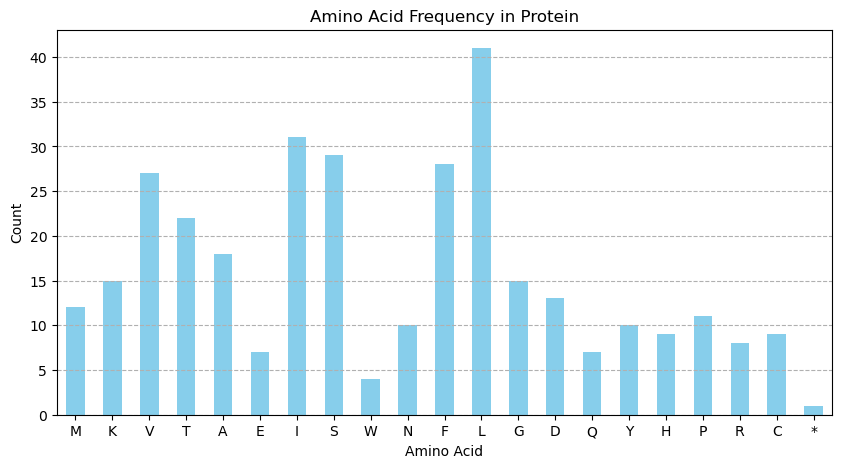

In [13]:
aa_counts_dict = Counter(str(protein_sequence))
aa_series = pd.Series(aa_counts_dict)
plt.figure(figsize=(10, 5))
aa_series.plot(kind='bar', color='skyblue')
plt.title('Amino Acid Frequency in Protein')
plt.xlabel('Amino Acid')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--')
plt.show()

- Dominant Amino Acid: Leucine (L) is the most frequent, with a count just over 40.

- High Frequency: Isoleucine (I) and Serine (S) are also very common (around 30).

- Low Frequency: Tryptophan (W) and the Stop Codon (*) are the least frequent (close to 0).